### Preservation

####  *AUTHOR:* Ehsan Farahbakhsh
####  *CONTACT:* e.farahbakhsh@sydney.edu.au
####  *DATE last modified:* 05/07/2025

In [1]:
from ipywidgets import interact
import warnings

import cartopy.crs as ccrs
import gplately
import joblib
from joblib import dump
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import differential_evolution
from scipy.stats import (
    fit,
    gengamma,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler

from lib.preservation import *
from lib.feature_extraction import *
from lib.predictive_modelling import *
from lib.prospectivity_map import *
from lib.plot import *

from parameters import parameters

In [2]:
# Timespan for analysis
temporal_resolution = parameters["temporal_resolution"]
time_min = parameters["timespan"]["min"]
time_max = parameters["timespan"]["max"]
time_steps = range(time_min, time_max + temporal_resolution, temporal_resolution)

grid_resolution = parameters["grid_resolution"]

plate_model_dir = parameters["plate_model_dir"]
inputs_dir = parameters["inputs_dir"]
outputs_dir = parameters["outputs_dir"]
ml_dir = parameters["ml_dir"]
pres_dir = parameters["pres_dir"]
backarc_pres_grids_dir = parameters["backarc_pres_grids_dir"]
backarc_pres_maps_dir = parameters["backarc_pres_maps_dir"]
coastline_pres_grids_dir = parameters["coastline_pres_grids_dir"]
coastline_pres_maps_dir = parameters["coastline_pres_maps_dir"]
backarc_prob_pres_grids_dir = parameters["backarc_prob_pres_grids_dir"]
backarc_prob_pres_maps_dir = parameters["backarc_prob_pres_maps_dir"]
coastline_prob_pres_grids_dir = parameters["coastline_prob_pres_grids_dir"]
coastline_prob_pres_maps_dir = parameters["coastline_prob_pres_maps_dir"]

ml_dir = os.path.join(outputs_dir, ml_dir)
pres_dir = os.path.join(outputs_dir, pres_dir)
if not os.path.exists(pres_dir):
    os.makedirs(pres_dir, exist_ok=True)
backarc_pres_grids_dir = os.path.join(pres_dir, "backarc_pres_grids")
backarc_pres_maps_dir = os.path.join(pres_dir, "backarc_pres_maps")
coastline_pres_grids_dir = os.path.join(pres_dir, "coastline_pres_grids")
coastline_pres_maps_dir = os.path.join(pres_dir, "coastline_pres_maps")
backarc_prob_pres_grids_dir = os.path.join(ml_dir, backarc_prob_pres_grids_dir)
backarc_prob_pres_maps_dir = os.path.join(ml_dir, backarc_prob_pres_maps_dir)
coastline_prob_pres_grids_dir = os.path.join(ml_dir, coastline_prob_pres_grids_dir)
coastline_prob_pres_maps_dir = os.path.join(ml_dir, coastline_prob_pres_maps_dir)

deposit_coords_recon_filename = parameters["deposit_coords_recon_filename"]
unlabelled_coords_filename = parameters["unlabelled_coords_filename"]
backarc_coords_filename = parameters["backarc_coords_filename"]
coastline_coords_filename = parameters["coastline_coords_filename"]
gengamma_dist_filename = parameters["gengamma_dist_filename"]
deposit_erodep_filename = parameters["deposit_erodep_filename"]
unlabelled_erodep_filename = parameters["unlabelled_erodep_filename"]
backarc_erodep_filename = parameters["backarc_erodep_filename"]
coastline_erodep_filename = parameters["coastline_erodep_filename"]
deposit_coords_recon_all_filename = parameters["deposit_coords_recon_all_filename"]
backarc_prob_filename = parameters["backarc_prob_filename"]
coastline_prob_filename = parameters["coastline_prob_filename"]
coastline_prob_present_day_filename = parameters["coastline_prob_present_day_filename"]
coastline_prob_pres_present_day_grid_filename = parameters["coastline_prob_pres_present_day_grid_filename"]
coastline_data_filename = parameters["coastline_data_filename"]

model_rf_calibrated_filename = parameters["model_rf_calibrated_filename"]

deposit_coords_recon_filename = os.path.join(outputs_dir, deposit_coords_recon_filename)
unlabelled_coords_filename = os.path.join(outputs_dir, unlabelled_coords_filename)
backarc_coords_filename = os.path.join(outputs_dir, backarc_coords_filename)
coastline_coords_filename = os.path.join(outputs_dir, coastline_coords_filename)
gengamma_dist_filename = os.path.join(pres_dir, gengamma_dist_filename)
deposit_erodep_filename = os.path.join(pres_dir, deposit_erodep_filename)
unlabelled_erodep_filename = os.path.join(pres_dir, unlabelled_erodep_filename)
backarc_erodep_filename = os.path.join(pres_dir, backarc_erodep_filename)
coastline_erodep_filename = os.path.join(pres_dir, coastline_erodep_filename)
deposit_coords_recon_all_filename = os.path.join(outputs_dir, deposit_coords_recon_all_filename)
backarc_prob_filename = os.path.join(ml_dir, backarc_prob_filename)
coastline_prob_filename = os.path.join(ml_dir, coastline_prob_filename)
coastline_prob_present_day_filename = os.path.join(ml_dir, coastline_prob_present_day_filename)
coastline_prob_pres_present_day_grid_filename = os.path.join(ml_dir, coastline_prob_pres_present_day_grid_filename)
coastline_data_filename = os.path.join(outputs_dir, coastline_data_filename)

model_rf_calibrated_filename = os.path.join(ml_dir, model_rf_calibrated_filename)

agegrid_dir = os.path.join(inputs_dir, "SeafloorAge")
erodep_dir = os.path.join(inputs_dir, "CumulativeErosionDeposition")

n_jobs = 20

### Coregistration

In [3]:
columns_erodep = ["present_lon", "present_lat", "lon", "lat", "age (Ma)"]

if os.path.isfile(deposit_erodep_filename):
    deposit_erodep = pd.read_csv(deposit_erodep_filename)
else:
    deposit_coords_recon = pd.read_csv(deposit_coords_recon_filename)
    deposit_erodep = deposit_coords_recon[columns_erodep]
    
    deposit_erodep = run_coregister_erosion_deposition(
        point_data=deposit_erodep,
        input_dir=erodep_dir,
        distance_threshold=0.1,
        output_filename=deposit_erodep_filename,
        n_jobs=n_jobs,
        verbose=True,
    )

if os.path.isfile(unlabelled_erodep_filename):
    unlabelled_erodep = pd.read_csv(unlabelled_erodep_filename)
else:
    unlabelled_coords = pd.read_csv(unlabelled_coords_filename)
    unlabelled_erodep = unlabelled_coords[columns_erodep]
    
    unlabelled_erodep = run_coregister_erosion_deposition(
        point_data=unlabelled_erodep,
        input_dir=erodep_dir,
        distance_threshold=0.1,
        output_filename=unlabelled_erodep_filename,
        n_jobs=n_jobs,
        verbose=True,
    )

if os.path.isfile(backarc_erodep_filename):
    backarc_erodep = pd.read_csv(backarc_erodep_filename)
else:
    backarc_coords = pd.read_csv(backarc_coords_filename)
    backarc_erodep = backarc_coords[columns_erodep]
    
    backarc_erodep = run_coregister_erosion_deposition(
        point_data=backarc_erodep,
        input_dir=erodep_dir,
        distance_threshold=0.1,
        output_filename=backarc_erodep_filename,
        n_jobs=n_jobs,
        verbose=True,
    )

if os.path.isfile(coastline_erodep_filename):
    coastline_erodep = pd.read_csv(coastline_erodep_filename)
else:
    coastline_coords = pd.read_csv(coastline_coords_filename)
    columns_erodep.append('index')
    coastline_erodep = coastline_coords[columns_erodep]
    
    coastline_erodep = run_coregister_erosion_deposition(
        point_data=coastline_erodep,
        input_dir=erodep_dir,
        distance_threshold=0.1,
        output_filename=coastline_erodep_filename,
        n_jobs=n_jobs,
        verbose=True,
    )

### Cumulative Erosion-Deposition

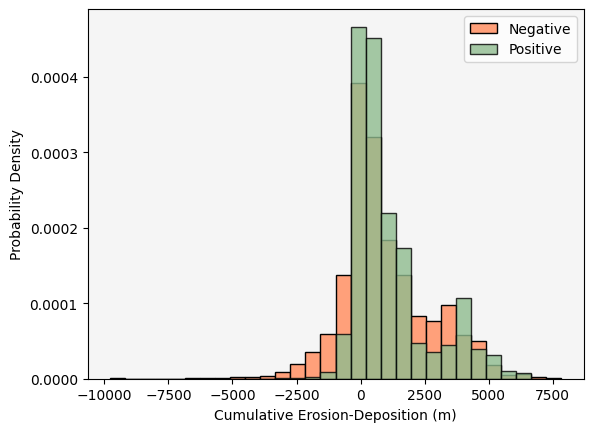

In [4]:
fig, ax = plt.subplots()
ax.set_facecolor('whitesmoke')

# Exclude zeros
deposit_erodep_filtered = deposit_erodep[deposit_erodep["erosion-deposition (m)"] != 0]
unlabelled_erodep_filtered = unlabelled_erodep[unlabelled_erodep["erosion-deposition (m)"] != 0]

_, bins, _ = ax.hist(
    unlabelled_erodep_filtered["erosion-deposition (m)"],
    bins=30,
    facecolor="LightSalmon",
    edgecolor='black',
    label="Negative",
    density=True,
    alpha=1,
)

ax.hist(
    deposit_erodep_filtered["erosion-deposition (m)"],
    bins=bins,
    facecolor="DarkSeaGreen",
    edgecolor="black",
    label="Positive",
    density=True,
    alpha=0.8,
)

ax.set_xlabel("Cumulative Erosion-Deposition (m)")
ax.set_ylabel("Probability Density")
ax.legend(loc="best")

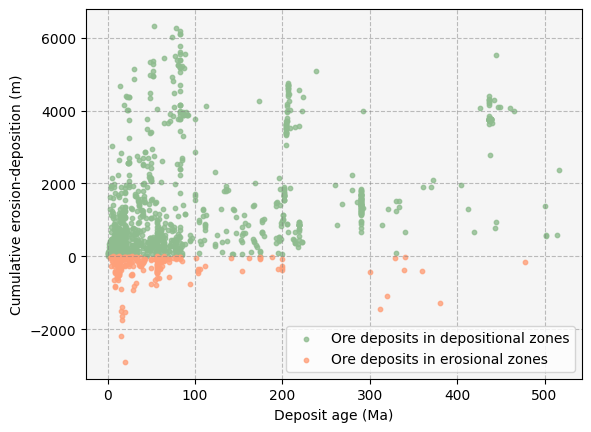

In [5]:
fig, ax = plt.subplots()
ax.set_facecolor('whitesmoke')

# Filter positive and negative values
deposition = deposit_erodep_filtered[deposit_erodep_filtered["erosion-deposition (m)"] > 0]
erosion = deposit_erodep_filtered[deposit_erodep_filtered["erosion-deposition (m)"] < 0]

# Plot deposition values in green
ax.scatter(
    deposition["age (Ma)"],
    deposition["erosion-deposition (m)"],
    facecolor="DarkSeaGreen",
    label="Ore deposits in depositional zones",
    alpha=0.8,
    s=10,
)

# Plot negative values in red
ax.scatter(
    erosion["age (Ma)"],
    erosion["erosion-deposition (m)"],
    facecolor="LightSalmon",
    label="Ore deposits in erosional zones",
    alpha=0.8,
    s=10,
)

ax.legend()
ax.set_xlabel("Deposit age (Ma)")
ax.set_ylabel("Cumulative erosion-deposition (m)")
ax.grid(linestyle="dashed", color="grey", alpha=0.5)

### Gamma Distribution

In [6]:
erosion_pos = erosion["erosion-deposition (m)"].abs()
erosion_pos_cleaned = clean_outliers(erosion_pos)

if os.path.isfile(gengamma_dist_filename):
    gengamma_dist = joblib.load(gengamma_dist_filename)
else:
    def optimize_func(*args, **kwargs):
        return differential_evolution(*args, seed=42, **kwargs)
    
    gengamma_bounds = {
        "a": (0.01, 50),
        "c": (-10, 10),
    }
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        fitted_params = fit(
            gengamma,
            data=erosion_pos_cleaned,
            bounds=gengamma_bounds,
            optimizer=optimize_func,
        )
    
    if not fitted_params.success:
        message = f"Optimisation failed! {fitted_params.message}"
        if failure == "raise":
            raise RuntimeError(message)
        else:
            warnings.warn(message, RuntimeWarning)
    
    gengamma_dist = gengamma(*(fitted_params.params))
    nll_parametric = -1 * gengamma_dist.logpdf(erosion_pos_cleaned).sum()
    
    dump(gengamma_dist, gengamma_dist_filename, compress=True)
    
    print(f"Parametric (gamma) distribution: NLL = {nll_parametric:0.0f}")
    print(f"""Writing parametric distribution to file: {gengamma_dist_filename}""")

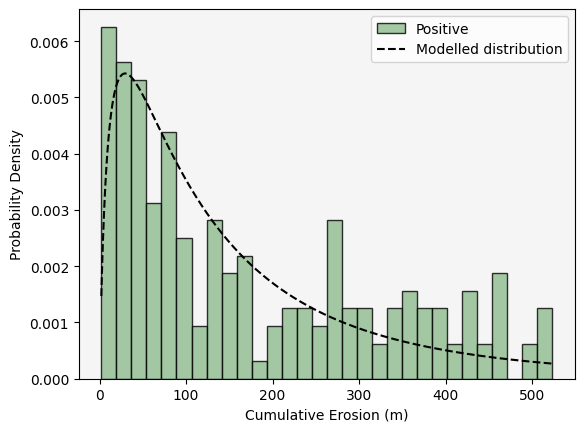

In [7]:
dist_x = np.linspace(
    erosion_pos_cleaned.min(),
    erosion_pos_cleaned.max(),
    500,
)
y_parametric = gengamma_dist.pdf(dist_x)

fig, ax = plt.subplots()
ax.set_facecolor('whitesmoke')

ax.hist(
    erosion_pos_cleaned,
    bins=30,
    facecolor="DarkSeaGreen",
    edgecolor="black",
    label="Positive",
    density=True,
    alpha=0.8,
)

ax.plot(
    dist_x,
    y_parametric,
    linestyle="dashed",
    color="black",
    label="Modelled distribution",
)

ax.set_xlabel("Cumulative Erosion (m)")
ax.set_ylabel("Probability Density")
ax.legend(loc="best")

### Q-Q Plot

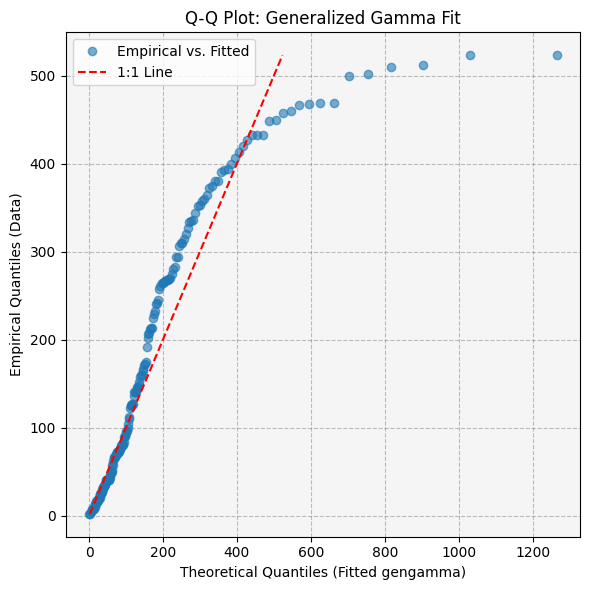

In [8]:
# Sort the empirical data
sorted_data = np.sort(erosion_pos_cleaned)

# Compute theoretical quantiles from the fitted distribution
quantiles = np.linspace(0, 1, len(sorted_data), endpoint=False)
theoretical_q = gengamma_dist.ppf(quantiles)

# Create Q-Q plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_facecolor('whitesmoke')  # Correct usage

ax.plot(theoretical_q, sorted_data, 'o', label="Empirical vs. Fitted", alpha=0.6)
ax.plot([sorted_data.min(), sorted_data.max()],
        [sorted_data.min(), sorted_data.max()],
        'r--', label="1:1 Line")

ax.set_xlabel("Theoretical Quantiles (Fitted gengamma)")
ax.set_ylabel("Empirical Quantiles (Data)")
ax.set_title("Q-Q Plot: Generalized Gamma Fit")
plt.legend()
plt.grid(linestyle="dashed", color="grey", alpha=0.5)
plt.tight_layout()
plt.show()

### Preservation Likelihood for Back-Arc Points

In [9]:
if "erosion (m)" in backarc_erodep.columns:
    print(f"Preservation likelihood has already been calculated and saved in {backarc_erodep_filename}")
else:
    backarc_erodep["erosion (m)"] = backarc_erodep["erosion-deposition (m)"]
    backarc_erodep.loc[backarc_erodep["erosion-deposition (m)"] > 0, "erosion (m)"] = 0
    backarc_erodep.loc[backarc_erodep["age (Ma)"] == 0, "erosion (m)"] = 0
    backarc_erodep.loc[(backarc_erodep["erosion-deposition (m)"] == 0) & (backarc_erodep["age (Ma)"] != 0), "erosion (m)"] = np.nan
    backarc_erodep['erosion (m)'] = backarc_erodep['erosion (m)'].abs()
    backarc_erodep["preservation_likelihood"] = gengamma_dist.pdf(backarc_erodep["erosion (m)"])
    preservation_likelihood = backarc_erodep["preservation_likelihood"].values
    preservation_likelihood_clean = preservation_likelihood[~np.logical_or(np.isnan(preservation_likelihood), preservation_likelihood == 0)].reshape(-1, 1)
    
    transformer = make_pipeline(
        FunctionTransformer(np.log, np.exp, check_inverse=False),
        MinMaxScaler()
    ).fit(preservation_likelihood_clean)
    
    preservation_likelihood_tran = transformer.transform(preservation_likelihood_clean)
    backarc_erodep.loc[~np.logical_or(np.isnan(preservation_likelihood), preservation_likelihood == 0.0), "preservation_likelihood_tran"] = preservation_likelihood_tran.flatten()
    backarc_erodep.loc[backarc_erodep['age (Ma)'] == 0, 'preservation_likelihood_tran'] = 1
    backarc_erodep.to_csv(backarc_erodep_filename, index=False)

if os.path.exists(backarc_pres_grids_dir):
    print(f"Preservation grids are located in {backarc_pres_grids_dir}")
else:
    os.makedirs(backarc_pres_grids_dir, exist_ok=True)

    create_grids(
        backarc_erodep,
        output_dir=backarc_pres_grids_dir,
        times=time_steps,
        resolution=grid_resolution,
        extent=(-180, 180, -90, 90),
        threads=n_jobs,
        verbose=True,
        column="preservation_likelihood_tran",
        filename_format="backarc_preservation_grid_{}Ma.nc",
    )

Preservation likelihood has already been calculated and saved in outputs\preservation\backarc_erodep.csv
Preservation grids are located in outputs\preservation\backarc_pres_grids


### Preservation Maps for Back-Arc Points

In [10]:
# muller22
rotation_model = [
    plate_model_dir+"/Rotations/1000_0_rotfile_MantleOpt.rot",
    plate_model_dir+"/Rotations/1000_0_rotfile_Merdith_etal_opt.rot",
    plate_model_dir+"/Rotations/lat_lon_velocity_domain_30_60.gpml",
    plate_model_dir+"/Rotations/no_net_rotation_model.rot",
]

topology_features = [
    plate_model_dir+"/Topologies/250-0_plate_bounds.gpml",
    plate_model_dir+"/Topologies/410-250_plate_bounds.gpml",
    plate_model_dir+"/Topologies/1000-410-Convergence.gpml",
    plate_model_dir+"/Topologies/1000-410-Divergence.gpml",
    plate_model_dir+"/Topologies/1000-410-Topologies.gpml",
    plate_model_dir+"/Topologies/1000-410-Transforms.gpml",
    plate_model_dir+"/Topologies/TopologyBuildingBlocks.gpml",
]

static_polygons = plate_model_dir+"/shapes_static_polygons_Merdith_etal.gpml"
coastlines = plate_model_dir+"/shapes_coastlines_Merdith_etal.gpmlz"
continents = plate_model_dir+"/shapes_continents.gpml"
COBs = plate_model_dir+"/COB_polygons_and_coastlines_combined_1000_0_Merdith_etal.gpml"

plate_reconstruction = PlateReconstruction(
    rotation_model=rotation_model,
    topology_features=topology_features,
    static_polygons=static_polygons,
)

gplot = PlotTopologies(
    plate_reconstruction=plate_reconstruction,
    coastlines=coastlines,
    continents=continents,
    COBs=COBs,
)

projection = ccrs.Mollweide(central_longitude=60)
central_meridian = 0

In [11]:
@interact
def show_map(time=time_steps):
    gplot.time = time
    fig = plot(
        gplot=gplot,
        grid=os.path.join(
            backarc_pres_grids_dir,
            f"backarc_preservation_grid_{time:0.0f}Ma.nc",
        ),
        grid_type="preservation",
        background_grid=os.path.join(
            agegrid_dir,
            f"seafloor_age_{time:0.0f}Ma.nc",
        ),
        # positives=deposit_coords_recon_all_filename,
        positives=None,
        projection=projection,
        time=time,
        central_meridian=central_meridian,
    )

interactive(children=(Dropdown(description='time', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, …

In [12]:
if os.path.exists(backarc_pres_maps_dir):
    print(f"Preservation likelihood maps are located in {backarc_pres_maps_dir}")
else:
    os.makedirs(backarc_pres_maps_dir, exist_ok=True)

    with Parallel(
        n_jobs=n_jobs,
        verbose=True,
        pre_dispatch="all",
        batch_size=int(len(time_steps) // n_jobs) + 1,
    ) as parallel:

        # Create all plots
        output_filenames = [
            os.path.join(backarc_pres_maps_dir, f"backarc_preservation_map_{t:0.0f}Ma.png")
            for t in time_steps
        ]

        parallel(
            delayed(plot_parallel)(
                rotation_model,
                topology_features,
                static_polygons,
                coastlines,
                continents,
                COBs,
                grid=os.path.join(
                    backarc_pres_grids_dir,
                    f"backarc_preservation_grid_{t:0.0f}Ma.nc",
                ),
                grid_type="preservation",
                background_grid=os.path.join(
                    agegrid_dir,
                    f"seafloor_age_{t:0.0f}Ma.nc",
                ),
                # positives=deposit_recon_coords_all_filename,
                positives=None,
                projection=projection,
                time=t,
                output_filename=o,
                central_meridian=central_meridian,
            )
            for t, o in zip(time_steps, output_filenames)
        )

    # Create animation
    output_filename = os.path.join(pres_dir, "backarc_preservation_animation.mp4")
    create_animation(
        image_filenames=output_filenames[::-1],
        output_filename=output_filename,
        fps=10,
        bitrate="5000k",
    )

Preservation likelihood maps are located in outputs\preservation\backarc_pres_maps


### Preserved Mineralisation Probability for Back-Arc Points

In [13]:
backarc_prob = pd.read_csv(backarc_prob_filename)

if "probability_pres" in backarc_prob.columns:
    print(f"Preserved mineralisation probability has already been calculated and saved in {backarc_prob_filename}")
else:
    backarc_prob = backarc_prob.sort_values(by=['age (Ma)', 'present_lon', 'present_lat'])
    backarc_erodep = backarc_erodep.sort_values(by=['age (Ma)', 'present_lon', 'present_lat'])
    
    backarc_prob['probability_pres'] = backarc_prob['probability'] * backarc_erodep['preservation_likelihood_tran'].fillna(1)
    backarc_prob.to_csv(backarc_prob_filename, index=False)
    
if os.path.exists(backarc_prob_pres_grids_dir):
    print(f"Preserved mineralisation probability grids are located in {backarc_prob_pres_grids_dir}")
else:
    os.makedirs(backarc_prob_pres_grids_dir, exist_ok=True)

    create_grids(
        backarc_prob,
        output_dir=backarc_prob_pres_grids_dir,
        times=time_steps,
        resolution=grid_resolution,
        extent=(-180, 180, -90, 90),
        threads=n_jobs,
        verbose=True,
        column="probability_pres",
        filename_format="backarc_probability_pres_grid_{}Ma.nc",
    )

Preserved mineralisation probability has already been calculated and saved in outputs\ml\backarc_prob.csv
Preserved mineralisation probability grids are located in outputs\ml\backarc_prob_pres_grids


In [14]:
@interact
def show_map(time=time_steps):
    gplot.time = time
    fig = plot(
        gplot=gplot,
        grid=os.path.join(
            backarc_prob_pres_grids_dir,
            f"backarc_probability_pres_grid_{time:0.0f}Ma.nc",
        ),
        grid_type="probability_pres",
        background_grid=os.path.join(
            agegrid_dir,
            f"seafloor_age_{time:0.0f}Ma.nc",
        ),
        positives=deposit_coords_recon_all_filename,
        projection=projection,
        time=time,
        central_meridian=central_meridian,
    )

interactive(children=(Dropdown(description='time', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, …

In [15]:
if os.path.exists(backarc_prob_pres_maps_dir):
    print(f"Preserved mineralisation probability maps are located in {backarc_prob_pres_maps_dir}")
else:
    os.makedirs(backarc_prob_pres_maps_dir, exist_ok=True)

    with Parallel(
        n_jobs=n_jobs,
        verbose=True,
        pre_dispatch="all",
        batch_size=int(len(time_steps) // n_jobs) + 1,
    ) as parallel:

        # Create all plots
        output_filenames = [
            os.path.join(backarc_prob_pres_maps_dir, f"backarc_probability_pres_map_{t:0.0f}Ma.png")
            for t in time_steps
        ]

        parallel(
            delayed(plot_parallel)(
                rotation_model,
                topology_features,
                static_polygons,
                coastlines,
                continents,
                COBs,
                grid=os.path.join(
                    backarc_prob_pres_grids_dir,
                    f"backarc_probability_pres_grid_{t:0.0f}Ma.nc",
                ),
                grid_type="probability_pres",
                background_grid=os.path.join(
                    agegrid_dir,
                    f"seafloor_age_{t:0.0f}Ma.nc",
                ),
                positives=deposit_coords_recon_all_filename,
                projection=projection,
                time=t,
                output_filename=o,
                central_meridian=central_meridian,
            )
            for t, o in zip(time_steps, output_filenames)
        )

    # Create animation
    output_filename = os.path.join(ml_dir, "backarc_probability_pres_animation.mp4")
    create_animation(
        image_filenames=output_filenames[::-1],
        output_filename=output_filename,
        fps=10,
        bitrate="5000k",
    )

Preserved mineralisation probability maps are located in outputs\ml\backarc_prob_pres_maps


### Preservation Likelihood for Points within Continents

In [16]:
if "erosion (m)" in coastline_erodep.columns:
    print(f"Preservation likelihood has already been calculated and saved in {coastline_erodep_filename}")
else:
    coastline_erodep["erosion (m)"] = coastline_erodep["erosion-deposition (m)"]
    coastline_erodep.loc[coastline_erodep["erosion-deposition (m)"] > 0, "erosion (m)"] = 0
    coastline_erodep.loc[coastline_erodep["age (Ma)"] == 0, "erosion (m)"] = 0
    coastline_erodep.loc[(coastline_erodep["erosion-deposition (m)"] == 0) & (coastline_erodep["age (Ma)"] != 0), "erosion (m)"] = np.nan
    coastline_erodep['erosion (m)'] = coastline_erodep['erosion (m)'].abs()
    coastline_erodep["preservation_likelihood"] = gengamma_dist.pdf(coastline_erodep["erosion (m)"])
    preservation_likelihood = coastline_erodep["preservation_likelihood"].values
    preservation_likelihood_clean = preservation_likelihood[~np.logical_or(np.isnan(preservation_likelihood), preservation_likelihood == 0)].reshape(-1, 1)
    
    transformer = make_pipeline(
        FunctionTransformer(np.log, np.exp, check_inverse=False),
        MinMaxScaler()
    ).fit(preservation_likelihood_clean)
    
    preservation_likelihood_tran = transformer.transform(preservation_likelihood_clean)
    coastline_erodep.loc[~np.logical_or(np.isnan(preservation_likelihood), preservation_likelihood == 0.0), "preservation_likelihood_tran"] = preservation_likelihood_tran.flatten()
    coastline_erodep.loc[coastline_erodep['age (Ma)'] == 0, 'preservation_likelihood_tran'] = 1
    coastline_erodep.to_csv(coastline_erodep_filename, index=False)

if os.path.exists(coastline_pres_grids_dir):
    print(f"Preservation grids are located in {coastline_pres_grids_dir}")
else:
    os.makedirs(coastline_pres_grids_dir, exist_ok=True)

    create_grids(
        coastline_erodep,
        output_dir=coastline_pres_grids_dir,
        times=time_steps,
        resolution=grid_resolution,
        extent=(-180, 180, -90, 90),
        interpolation=True,
        threads=n_jobs,
        verbose=True,
        column="preservation_likelihood_tran",
        filename_format="coastline_preservation_grid_{}Ma.nc",
    )

Preservation likelihood has already been calculated and saved in outputs\preservation\coastline_erodep.csv
Preservation grids are located in outputs\preservation\coastline_pres_grids


### Preservation Maps for Points within Continents

In [17]:
@interact
def show_map(time=time_steps):
    gplot.time = time
    fig = plot(
        gplot=gplot,
        grid=os.path.join(
            coastline_pres_grids_dir,
            f"coastline_preservation_grid_{time:0.0f}Ma.nc",
        ),
        grid_type="preservation",
        background_grid=os.path.join(
            agegrid_dir,
            f"seafloor_age_{time:0.0f}Ma.nc",
        ),
        # positives=deposit_coords_recon_all_filename,
        positives=None,
        projection=projection,
        time=time,
        central_meridian=central_meridian,
    )

interactive(children=(Dropdown(description='time', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, …

In [18]:
if os.path.exists(coastline_pres_maps_dir):
    print(f"Preservation likelihood maps are located in {coastline_pres_maps_dir}")
else:
    os.makedirs(coastline_pres_maps_dir, exist_ok=True)

    with Parallel(
        n_jobs=n_jobs,
        verbose=True,
        pre_dispatch="all",
        batch_size=int(len(time_steps) // n_jobs) + 1,
    ) as parallel:

        # Create all plots
        output_filenames = [
            os.path.join(coastline_pres_maps_dir, f"coastline_preservation_map_{t:0.0f}Ma.png")
            for t in time_steps
        ]

        parallel(
            delayed(plot_parallel)(
                rotation_model,
                topology_features,
                static_polygons,
                coastlines,
                continents,
                COBs,
                grid=os.path.join(
                    coastline_pres_grids_dir,
                    f"coastline_preservation_grid_{t:0.0f}Ma.nc",
                ),
                grid_type="preservation",
                background_grid=os.path.join(
                    agegrid_dir,
                    f"seafloor_age_{t:0.0f}Ma.nc",
                ),
                # positives=deposit_recon_coords_all_filename,
                positives=None,
                projection=projection,
                time=t,
                output_filename=o,
                central_meridian=central_meridian,
            )
            for t, o in zip(time_steps, output_filenames)
        )

    # Create animation
    output_filename = os.path.join(pres_dir, "coastline_preservation_animation.mp4")
    create_animation(
        image_filenames=output_filenames[::-1],
        output_filename=output_filename,
        fps=10,
        bitrate="5000k",
    )

Preservation likelihood maps are located in outputs\preservation\coastline_pres_maps


### Preserved Mineralisation Probability for Points within Continents

In [19]:
coastline_prob = pd.read_csv(coastline_prob_filename)

if "probability_pres" in coastline_prob.columns:
    print(f"Preserved mineralisation probability has already been calculated and saved in {coastline_prob_filename}")
else:
    coastline_prob = coastline_prob.sort_values(by=['age (Ma)', 'present_lon', 'present_lat'])
    coastline_erodep = coastline_erodep.sort_values(by=['age (Ma)', 'present_lon', 'present_lat'])
    
    coastline_prob['probability_pres'] = coastline_prob['probability'] * coastline_erodep['preservation_likelihood_tran'].fillna(1)
    coastline_prob.to_csv(coastline_prob_filename, index=False)
    
if os.path.exists(coastline_prob_pres_grids_dir):
    print(f"Preserved mineralisation probability grids are located in {coastline_prob_pres_grids_dir}")
else:
    os.makedirs(coastline_prob_pres_grids_dir, exist_ok=True)

    create_grids(
        coastline_prob,
        output_dir=coastline_prob_pres_grids_dir,
        times=time_steps,
        resolution=grid_resolution,
        extent=(-180, 180, -90, 90),
        interpolation=True,
        threads=n_jobs,
        verbose=True,
        column="probability_pres",
        filename_format="coastline_probability_pres_grid_{}Ma.nc",
    )

Preserved mineralisation probability has already been calculated and saved in outputs\ml\coastline_prob.csv
Preserved mineralisation probability grids are located in outputs\ml\coastline_prob_pres_grids


In [20]:
@interact
def show_map(time=time_steps):
    gplot.time = time
    fig = plot(
        gplot=gplot,
        grid=os.path.join(
            coastline_prob_pres_grids_dir,
            f"coastline_probability_pres_grid_{time:0.0f}Ma.nc",
        ),
        grid_type="probability_pres",
        background_grid=os.path.join(
            agegrid_dir,
            f"seafloor_age_{time:0.0f}Ma.nc",
        ),
        positives=deposit_coords_recon_all_filename,
        projection=projection,
        time=time,
        central_meridian=central_meridian,
    )

interactive(children=(Dropdown(description='time', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, …

In [21]:
if os.path.exists(coastline_prob_pres_maps_dir):
    print(f"Preserved mineralisation probability maps are located in {coastline_prob_pres_maps_dir}")
else:
    os.makedirs(coastline_prob_pres_maps_dir, exist_ok=True)

    with Parallel(
        n_jobs=n_jobs,
        verbose=True,
        pre_dispatch="all",
        batch_size=int(len(time_steps) // n_jobs) + 1,
    ) as parallel:

        # Create all plots
        output_filenames = [
            os.path.join(coastline_prob_pres_maps_dir, f"coastline_probability_pres_map_{t:0.0f}Ma.png")
            for t in time_steps
        ]

        parallel(
            delayed(plot_parallel)(
                rotation_model,
                topology_features,
                static_polygons,
                coastlines,
                continents,
                COBs,
                grid=os.path.join(
                    coastline_prob_pres_grids_dir,
                    f"coastline_probability_pres_grid_{t:0.0f}Ma.nc",
                ),
                grid_type="probability_pres",
                background_grid=os.path.join(
                    agegrid_dir,
                    f"seafloor_age_{t:0.0f}Ma.nc",
                ),
                positives=deposit_coords_recon_all_filename,
                projection=projection,
                time=t,
                output_filename=o,
                central_meridian=central_meridian,
            )
            for t, o in zip(time_steps, output_filenames)
        )

    # Create animation
    output_filename = os.path.join(ml_dir, "coastline_probability_pres_animation.mp4")
    create_animation(
        image_filenames=output_filenames[::-1],
        output_filename=output_filename,
        fps=10,
        bitrate="5000k",
    )

Preserved mineralisation probability maps are located in outputs\ml\coastline_prob_pres_maps


### Global Prospectivity Map of Preserved Porphyry Mineralisation

In [22]:
coastline_prob_present_day = pd.read_csv(coastline_prob_present_day_filename)

if "probability_pres" in coastline_prob_present_day.columns:
    print(f"Preserved mineralisation probability has already been calculated and saved in {coastline_prob_present_day_filename}")
else:
    coastline_prob = coastline_prob[coastline_prob['probability_pres'] > 0.5]
    coastline_prob_mean = coastline_prob.groupby('index')[['probability_pres']].mean().reset_index()
    coastline_prob_present_day = pd.merge(coastline_prob_present_day, coastline_prob_mean, on='index', how='left')
    coastline_prob_present_day = coastline_prob_present_day[['index', 'present_lon', 'present_lat', 'probability', 'entropy', 'vote_variance', 'probability_pres']]
    coastline_prob_present_day.to_csv(coastline_prob_present_day_filename, index=False)

Preserved mineralisation probability has already been calculated and saved in outputs\ml\coastline_prob_present_day.csv


In [23]:
model_rf_calibrated = joblib.load(model_rf_calibrated_filename)
selected_features = model_rf_calibrated.feature_names_in_

deposit_coords_recon = pd.read_csv(deposit_coords_recon_filename)

# Rolling window to smooth the curve
coastline_prob = coastline_prob[coastline_prob['probability_pres'] > 0.5]
coastline_prob_mean_age = coastline_prob.groupby('age (Ma)')['probability_pres'].mean().reset_index()
coastline_prob_mean_age['smoothed'] = coastline_prob_mean_age['probability_pres'].rolling(window=10, center=True).mean()

# Sort by age to ensure correct ordering
coastline_prob_mean_age = coastline_prob_mean_age.sort_values('age (Ma)')

# Define input and target
ages = coastline_prob_mean_age['age (Ma)'].values.reshape(-1, 1)
probs = coastline_prob_mean_age['probability_pres'].values

ages_smooth, probs_smooth = smooth_curve(ages, probs)

coastline_data = pd.read_csv(coastline_data_filename)

@interact
def show_map(feature=selected_features):
    coastline_feat_mean_age = coastline_prob.merge(coastline_data[['index', 'age (Ma)', feature]], on=['index', 'age (Ma)'], how='left')
    coastline_feat_mean_age = coastline_feat_mean_age.groupby('age (Ma)')[feature].mean().reset_index()
    coastline_feat_mean_age = coastline_feat_mean_age.sort_values('age (Ma)')
    feat_vals = coastline_feat_mean_age[feature].values
    _, feat_vals_smooth = smooth_curve(ages, feat_vals)
    
    # Set up plot with dual y-axes
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.set_facecolor('whitesmoke')
    
    # Plot smoothed probability line
    ax1.plot(ages_smooth, probs_smooth, color='orangered', linewidth=2, label='KRR Smoothed')
    ax1.set_xlim(540, 0)
    ax1.set_ylim(0.5, 0.85)
    ax1.set_xlabel('Age (Ma)')
    ax1.set_ylabel('Mean probability (P > 0.5)', color='orangered')
    ax1.set_title('Mean Probability and Deposit Frequency by Age')
    
    # Create secondary y-axis for histogram
    ax2 = ax1.twinx()
    
    # Plot histogram
    ax2.hist(deposit_coords_recon['age (Ma)'], bins=40, orientation='vertical', color='LightSalmon', alpha=0.5, edgecolor='gray')
    ax2.set_ylabel('Deposit count')
    
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))  # shift third axis to the right
    ax3.plot(ages_smooth, feat_vals_smooth,
             linestyle='-', color='royalblue', label=format_feature_name(feature))
    ax3.set_ylabel(format_feature_name(feature), color='royalblue')
        
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='feature', options=('arc_segment_length (degrees)', 'carbonate_thic…

In [24]:
if not os.path.isfile(coastline_prob_pres_present_day_grid_filename):
    xmin, xmax, ymin, ymax = -180, 180, -90, 90

    # Create the grid
    grid_lons = np.arange(xmin, xmax + grid_resolution, grid_resolution)
    grid_lats = np.arange(ymin, ymax + grid_resolution, grid_resolution)
    grid_mlons, grid_mlats = np.meshgrid(grid_lons, grid_lats)

    data_lons = coastline_prob_present_day['present_lon']
    data_lats = coastline_prob_present_day['present_lat']
    data_values = coastline_prob_present_day['probability_pres']

    # Interpolate
    points = np.column_stack((data_lons, data_lats))
    arr = griddata(points, data_values, (grid_mlons, grid_mlats), method="nearest")  # or "linear", "cubic"

    # Mask distant grid nodes
    tree = cKDTree(points)
    flat_grid_points = np.column_stack((grid_mlons.ravel(), grid_mlats.ravel()))
    distances, _ = tree.query(flat_grid_points, k=1)

    mask = distances > grid_resolution
    arr.ravel()[mask] = np.nan  # Mask out distant nodes        

    # Create the dataset
    dset = xr.Dataset(
        data_vars={
            "z": (("lat", "lon"), arr),
        },
        coords={
            "lon": grid_lons,
            "lat": grid_lats,
        },
    )

    # Set projection info
    dset.rio.write_crs(4326, inplace=True)

    # Save as NetCDF
    dset.to_netcdf(
        coastline_prob_pres_present_day_grid_filename,
        encoding={
            "z": {
                "zlib": True,
                "dtype": "float32",
            }
        },
    )

C:\Users\efar0517\AppData\Local\Temp\ipykernel_21140\987520167.py:33: DeprecationWarning: Deprecated! The 'plot_ridges_and_transforms' function will be removed in the future GPlately releases. Update your workflow to use the 'plot_ridges' and 'plot_transforms' functions instead, otherwise your workflow will not work with the future GPlately releases.


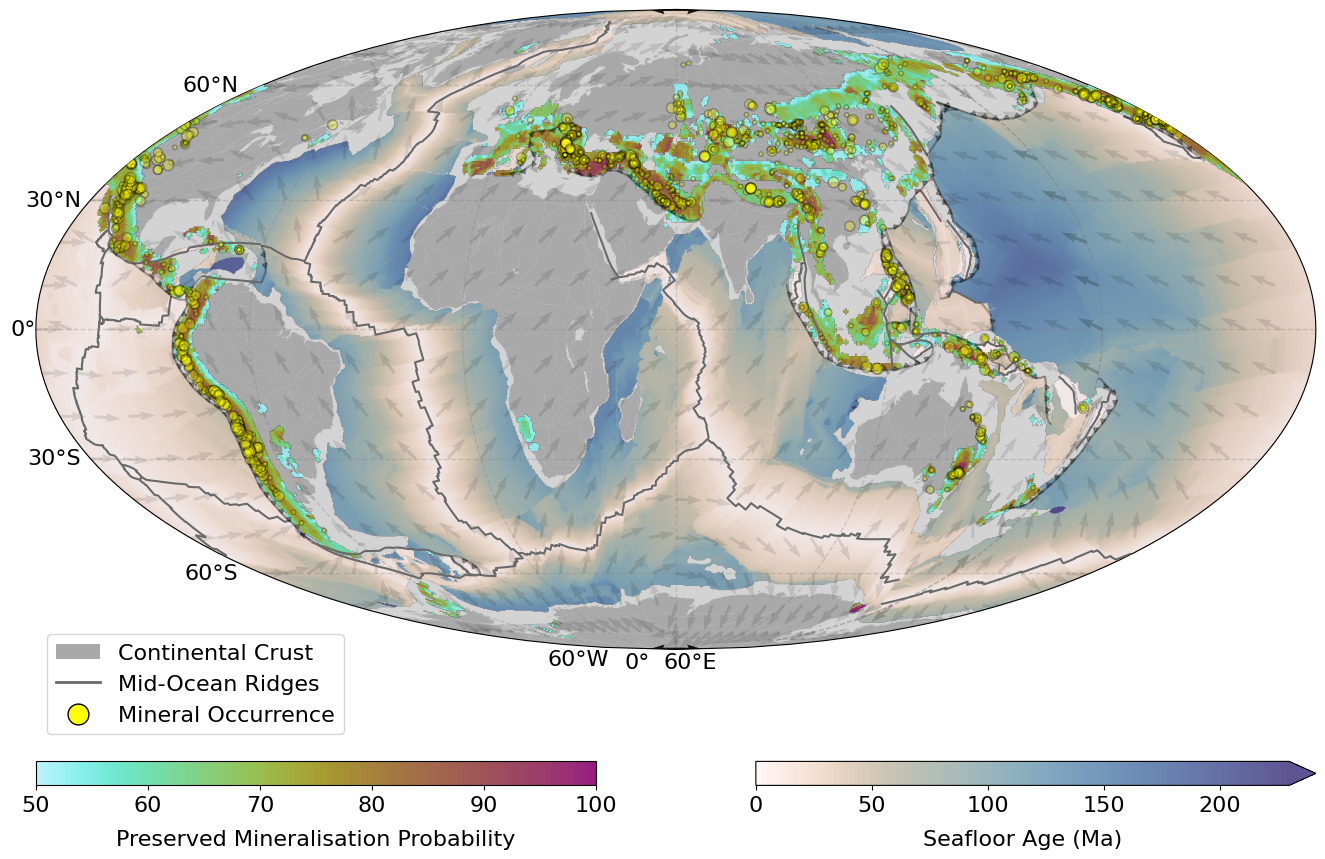

In [25]:
deposit_coords_recon_all = pd.read_csv(deposit_coords_recon_all_filename)
time = 0

gplot.time = time

deposit_coords_recon_t = deposit_coords_recon_all[[f'lon_{time}', f'lat_{time}', 'weight']]
deposit_coords_recon_t = deposit_coords_recon_t.dropna()
    
agegrid_filename =  f'seafloor_age_{time}Ma.nc'
agegrid_file = os.path.join(agegrid_dir, agegrid_filename)    
agegrid = gplately.grids.read_netcdf_grid(agegrid_file)

raster = Raster(coastline_prob_pres_present_day_grid_filename)
raster.data *= 100.0
        
fig = plt.figure(figsize=(16, 12))
ax = fig.add_axes(
    [0.1, 0.1, 0.8, 0.8],
    projection=projection,
    facecolor=(plt.cm.colors.to_rgba('darkgray', alpha=0.5)),
)

cax_grd = fig.add_axes([0.1, 0.12, 0.35, 0.02])
cax_bg = fig.add_axes([0.55, 0.12, 0.35, 0.02])

bg = gplot.plot_grid(ax, agegrid.data, cmap=ccm.lapaz_r, vmin=0, vmax=230, alpha=0.7, zorder=1)

gplot.plot_coastlines(ax, facecolor='darkgray', edgecolor='none', zorder=2)
gplot.plot_plate_motion_vectors(ax, spacingX=10, spacingY=10, normalise=True, alpha=0.1, zorder=3)

grd = raster.imshow(ax=ax, cmap=ccm.hawaii_r, vmin=50, vmax=100, alpha=0.9, zorder=4)

gplot.plot_ridges_and_transforms(ax, color='dimgray', linewidth=1.5, zorder=5)
gplot.plot_trenches(ax, color='k', alpha=0.3, zorder=6)
gplot.plot_subduction_teeth(ax, spacing=0.05, color='k', alpha=0.3, zorder=7)

sc1 = ax.scatter(
    deposit_coords_recon_t[f'lon_{time}'],
    deposit_coords_recon_t[f'lat_{time}'],
    transform=ccrs.PlateCarree(),
    marker='o',
    facecolor='yellow',
    edgecolor='black',
    s = [w * 10 for w in deposit_coords_recon_t['weight']],
    alpha=0.3,
    zorder=8
)

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, x_inline=False, linewidth=1, color="gray", alpha=0.3, linestyle="--", zorder=9)

ax.text(0.49,-0.03, '60°E', transform=ax.transAxes, fontsize=16)
ax.text(0.46,-0.03, '0°', transform=ax.transAxes, fontsize=16)
ax.text(0.40,-0.025, '60°W', transform=ax.transAxes, fontsize=16)

gl.top_labels=False
gl.bottom_labels=False

gl.xlabel_style = {"size": 16}
gl.ylabel_style = {"size": 16}

cbar_grd = fig.colorbar(grd, cax=cax_grd, orientation="horizontal")
cbar_grd.set_label("Preserved Mineralisation Probability", fontsize=16, labelpad=10)
cbar_grd.ax.tick_params(labelsize=16)

cbar_bg = fig.colorbar(bg, cax=cax_bg, orientation="horizontal", extend='max')
cbar_bg.set_label("Seafloor Age (Ma)", fontsize=16, labelpad=10)
cbar_bg.set_ticks([0, 50, 100, 150, 200])
cbar_bg.ax.tick_params(labelsize=16)

# Define custom legend handles
custom_handles = [
    Patch(facecolor='darkgray', edgecolor='none', label='Continental Crust'),
    Line2D([0], [0], color='dimgray', lw=2, label='Mid-Ocean Ridges'),
    Line2D([0], [0], marker='o', markerfacecolor='yellow', markeredgecolor='black', markersize=15, linestyle='None', label='Mineral Occurrence')
]

# Add the custom legend to the plot
legend = ax.legend(handles=custom_handles, fontsize=16, loc='lower left', bbox_to_anchor=(0, -0.15))

#     ax.set_title('Global Prospectivity Map of Preserved Porphyry Mineralisation', fontsize=25, y=1.04)

plt.show()

### Prediction-Area Plot

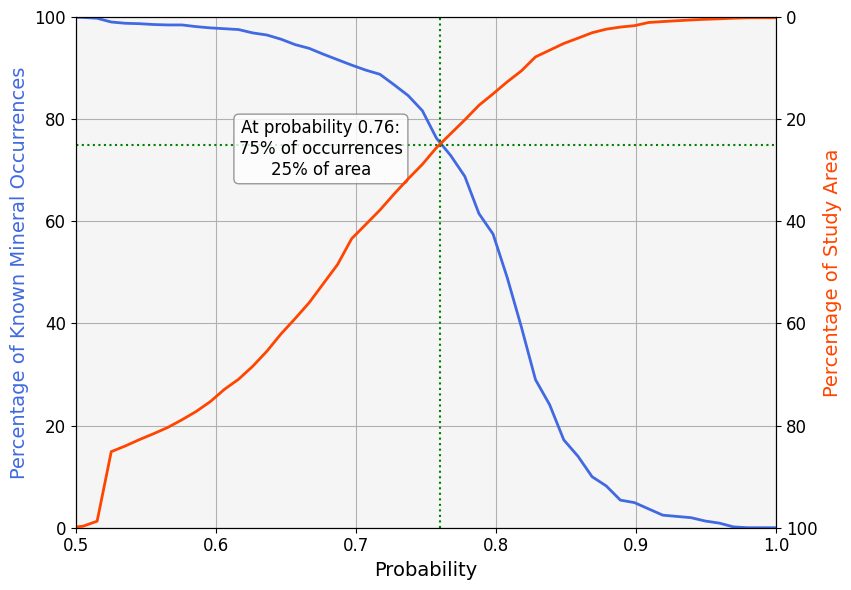

In [26]:
# Load prospectivity data
prospectivity_data = xr.open_dataset(coastline_prob_pres_present_day_grid_filename)
prospectivity_data = prospectivity_data['z'].squeeze()

# Extract probability values at known mineral occurrence locations
occurrence_probabilities = []
for _, row in deposit_coords_recon.iterrows():
    lon, lat = row['present_lon'], row['present_lat']
    # Extract probability value at this point
    prob_value = prospectivity_data.sel(lon=lon, lat=lat, method='nearest').item()
    occurrence_probabilities.append(prob_value)

# Convert to numpy array for easier manipulation
occurrence_probabilities = np.array(occurrence_probabilities)
occurrence_probabilities = occurrence_probabilities[~np.isnan(occurrence_probabilities)]

# Calculate total study area and number of valid cells
total_area = np.count_nonzero(~np.isnan(prospectivity_data))
total_occurrences = len(occurrence_probabilities)

# Define the probability thresholds
thresholds = np.linspace(0, 1, 100)

# Initialize lists to store results
occurrence_percentages = []
area_percentages = []

# Calculate percentages for each threshold
for threshold in thresholds:
    occurrence_percentage = np.sum(occurrence_probabilities >= threshold) / total_occurrences * 100
    area_percentage = np.sum(prospectivity_data >= threshold) / total_area * 100
    occurrence_percentages.append(occurrence_percentage)
    area_percentages.append(area_percentage)

# Convert lists to numpy arrays for plotting
occurrence_percentages = np.array(occurrence_percentages)
area_percentages = np.array(area_percentages)

# Set the font sizes
SMALL_SIZE = 12
MEDIUM_SIZE = 14
LARGE_SIZE = 16

# Create the P-A plot
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_facecolor('whitesmoke')

# Plot the occurrence percentages
ax1.plot(thresholds, occurrence_percentages, color='royalblue', linewidth=2)
ax1.set_xlabel('Probability', fontsize=MEDIUM_SIZE)
ax1.set_ylabel('Percentage of Known Mineral Occurrences', color='royalblue', fontsize=MEDIUM_SIZE)
ax1.set_ylim(0, 100)
ax1.set_xlim(0.5, 1)
ax1.grid(True)

# Increase tick label sizes
ax1.tick_params(axis='both', labelsize=SMALL_SIZE)

# Create a second y-axis to plot the area percentages
ax2 = ax1.twinx()
ax2.plot(thresholds, area_percentages, color='orangered', linewidth=2)
ax2.set_ylabel('Percentage of Study Area', color='orangered', fontsize=MEDIUM_SIZE)
ax2.set_ylim(100, 0)  # Inverted y-axis
ax2.tick_params(axis='y', labelsize=SMALL_SIZE)

# Add horizontal and vertical lines
intersection_x = 0.76
intersection_y1 = 75
intersection_y2 = 25
h_line = ax1.hlines(y=intersection_y1, xmin=0, xmax=1, color='g', linestyles=':')
v_line = ax1.vlines(x=intersection_x, ymin=0, ymax=100, color='g', linestyles=':')

# Add annotations for the lines
# X-axis annotation
# ax1.annotate(f'{intersection_x}', xy=(intersection_x, -0.06), xycoords='data',
#              xytext=(0, -20), textcoords='offset points',
#              ha='center', va='top', color='g',
#              arrowprops=dict(arrowstyle='->', color='g'))

# # Left Y-axis (Percentage of Known Mineral Occurrences) annotation
# ax1.annotate(f'{intersection_y1}%', xy=(0, intersection_y1), xycoords='data',
#              xytext=(-25, 0), textcoords='offset points',
#              ha='right', va='center', color='g',
#              arrowprops=dict(arrowstyle='->', color='g', shrinkA=0, shrinkB=4))

# # Right Y-axis (Percentage of Study Area) annotation
# ax2.annotate(f'{intersection_y2}%', xy=(1, intersection_y2), xycoords='data',
#              xytext=(25, 0), textcoords='offset points',
#              ha='left', va='center', color='g',
#              arrowprops=dict(arrowstyle='->', color='g', shrinkA=0, shrinkB=4))

# Add a text box to explain the intersection point with larger font
ax1.annotate(f'At probability {intersection_x}:\n{intersection_y1}% of occurrences\n{intersection_y2}% of area',
             xy=(0.35, 0.8), xycoords='axes fraction',
             ha='center', va='top',
             fontsize=SMALL_SIZE,
             bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))

# plt.title('Prediction-Area Plot')
plt.tight_layout()  # Adjust layout to prevent clipping of labels

# Adjust the plot margins to make room for annotations
plt.subplots_adjust(left=0.15, right=0.85)

# plt.savefig(
# f'./figures/pa_ng.png',
# bbox_inches='tight',
# pad_inches=0.1,
# dpi=200
# )

plt.show()